In [1]:
import pandas as pd
import numpy as np
import sklearn
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import cross_val_score, KFold, cross_val_predict
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import explained_variance_score, r2_score, mean_absolute_error
from sklearn.linear_model import LinearRegression, Lasso, Ridge
from sklearn.pipeline import Pipeline
import matplotlib.pyplot as plt


In [2]:
df=pd.read_table('Fig1c.txt')
df.head()

,Accession_ID,Name,Country,Latitude,Longitude,CS_number,material,material_Country,Mg25,bio1,...,ph,CN,CEC,CaCO3,N,P,K,Mg,PC1,PC2
0,8241,Liarum,Sweden,55.9473,13.8210,CS77038,leaf,Sweden_leaf,6425.217028,6.800000,...,5.099498,16.017828,11.404053,8.995235,2.903223,34.881931,99.043198,37,-0.019888,-0.023376
1,6203,TDr-18,Sweden,55.7714,14.1208,CS77350,leaf,Sweden_leaf,6106.090545,7.400000,...,5.306688,16.933012,11.273796,11.339157,2.775039,43.916851,128.464050,40,-0.010401,-0.032897
2,5984,DraIV 6-13,Czech Republic,49.4112,16.2815,CS76822,leaf,Czech Republic_leaf,5937.667641,7.395833,...,5.724783,10.382457,11.531424,0.000000,2.134119,38.884171,205.518021,47,-0.048688,-0.004639
3,9399,Hamm-1,Sweden,55.4234,13.9905,CS76910,leaf,Sweden_leaf,5936.194976,7.937500,...,6.321225,11.384063,13.246228,10.353964,2.153087,56.946087,138.103867,39,-0.010179,-0.026704
4,8420,Kelsterbach-4,GER,50.0667,8.5333,CS76525,leaf,GER_leaf,5842.619693,10.337500,...,6.733436,13.335432,11.836184,54.417881,1.570549,32.795654,158.965622,43,-0.028367,0.003936


In [3]:
df=df.rename(columns={'coarse_frag':'coarse frag',
                   'bulk_density':'bulk density',
                   'CaCO3':'CaCO$_3$',
                     'ph':'pH',
                     'ai':'AI',
                     'awc':'AWC'})

In [4]:
df=df[df.duplicated(subset=['Country'],keep=False)]

In [5]:
X=df.drop(columns=['Mg25'])
y=df['Mg25']

In [6]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 1)

In [7]:
X_train=X_train.select_dtypes(include='number')
X_train=X_train.drop(columns=['Accession_ID','Latitude','Longitude'])
X_train.head()

,bio1,bio2,bio3,bio4,bio5,bio6,bio7,bio8,bio9,bio10,...,pH,CN,CEC,CaCO$_3$,N,P,K,Mg,PC1,PC2
188,8.479167,7.008333,38.088768,424.100433,19.000000,0.6,18.4,8.883333,5.200000,14.016666,...,5.309776,15.969325,18.667496,74.473305,2.908743,29.603725,166.007599,41,-0.001539,-0.004080
317,7.783333,6.833333,28.954802,643.835571,21.100000,-2.5,23.6,4.650000,2.666667,15.966667,...,5.988177,14.969644,9.420408,6.893508,1.767194,34.157993,112.461731,37,0.001714,-0.058532
162,9.804167,7.091667,33.769840,512.992371,21.600000,0.6,21.0,10.683333,5.883333,16.116667,...,6.958485,9.993786,9.929628,26.639885,2.589607,53.894737,260.111084,37,-0.013351,0.029264
616,10.008333,9.683333,33.506344,724.364441,25.600000,-3.3,28.9,6.233333,18.416666,18.916668,...,5.348785,14.462580,16.551249,2.945889,1.524456,4.798762,206.728210,34,-0.010535,0.015107
326,13.120833,8.625000,43.125000,423.794861,23.799999,3.8,20.0,11.083333,18.383333,18.650000,...,6.706738,12.072179,18.370918,138.761948,2.736146,10.215800,211.943863,40,0.000881,0.018317


In [8]:
X_test=X_test.select_dtypes(include='number')
X_test=X_test.drop(columns=['Accession_ID','Latitude','Longitude'])
X_test.head()

,bio1,bio2,bio3,bio4,bio5,bio6,bio7,bio8,bio9,bio10,...,pH,CN,CEC,CaCO$_3$,N,P,K,Mg,PC1,PC2
407,15.412500,9.691667,39.719944,552.136841,28.600000,4.2,24.400002,10.216667,22.299999,22.299999,...,7.336013,10.289663,17.509703,60.877995,2.114833,32.692707,427.364594,43,-0.022562,0.022006
615,16.529167,7.825000,32.468880,607.986450,30.200001,6.1,24.100000,13.883333,24.200001,24.233334,...,7.598414,9.936677,14.772600,101.750450,1.480609,11.967968,205.761917,51,-0.024748,0.024046
378,12.929167,11.225000,35.748409,716.048035,31.299999,-0.1,31.400000,8.650000,22.233334,22.416666,...,6.589819,11.735341,10.378104,43.847084,1.333466,6.608674,215.566559,33,0.121344,0.053729
499,8.650000,7.033333,36.631943,454.077484,19.600000,0.4,19.200001,4.416667,12.866667,14.466666,...,5.686490,12.865416,9.941420,21.108318,3.329602,34.973095,151.055954,49,0.028227,-0.020909
58,10.066667,6.683333,32.131409,523.025879,21.500000,0.7,20.799999,10.950000,8.933333,16.516666,...,6.460595,14.590979,10.351868,60.002895,1.773701,26.090187,125.968071,42,0.012272,-0.016238


In [9]:
from sklearn.model_selection import GridSearchCV
parameters={'max_depth':list(range(2,7)),
           'max_leaf_nodes':list(range(2,10)),
           'n_estimators':[100,200]}
forest_model= RandomForestRegressor(random_state = 1)
forest_model_cv=GridSearchCV(forest_model,parameters,cv=4)
forest_model_cv.fit(X_train,y_train)
print(forest_model_cv.best_params_)
print(forest_model_cv.best_score_)

{'max_depth': 4, 'max_leaf_nodes': 5, 'n_estimators': 200}
0.16290309394842817


In [10]:
y_pred=forest_model_cv.predict(X_test)
from sklearn.metrics import explained_variance_score, r2_score, mean_absolute_error
mae = mean_absolute_error(y_test.values.ravel(), y_pred)
mse = mean_squared_error(y_test, y_pred)
explained_variance_score(y_test,y_pred)
r2 = r2_score(y_test.values.ravel(), y_pred)
print('Mean Absolute Error:', round(mae, 2))
print('Mean Squared Error:', round(mse, 2))
print('R-squared scores:', round(r2, 2))

Mean Absolute Error: 298.02
Mean Squared Error: 140837.5
R-squared scores: 0.23


In [11]:
from sklearn.inspection import permutation_importance

result = permutation_importance(forest_model_cv, X_test, y_test, n_repeats=1000, n_jobs=4)
model_importances = pd.Series(result.importances_mean, index=X_train.columns)

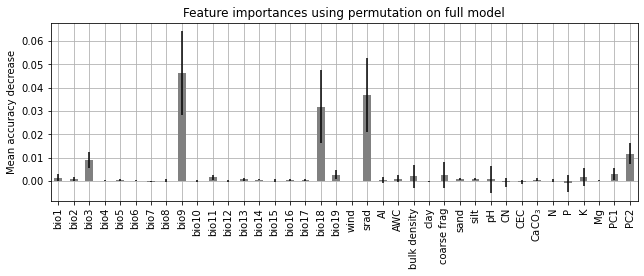

In [12]:
cm=1/2.54
fig, ax= plt.subplots(figsize=(23*cm,10*cm))
model_importances.plot.bar(yerr=result.importances_std, ax=ax,color='grey',zorder=2.5)
ax.set_title("Feature importances using permutation on full model")
ax.set_ylabel("Mean accuracy decrease")
ax.xaxis.grid(True)
ax.yaxis.grid(True)
fig.tight_layout()
# plt.savefig("Fig1c_20240919.pdf", format="pdf",bbox_inches="tight",facecolor="w")